In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append("./models")

from cir.simulation import DataSimulation
from cir.gan_integrated_sim import GANIntegratedSimulation
from change_point.simulation import ChangePointInjector
from models.noise_gan.wgan_gp_residuals import Generator

In [2]:
def read_and_combine_files(file_patterns, asset_name):
    """Читает и объединяет CSV файлы для одного актива"""
    dfs = []
    for file in file_patterns:
        df = pd.read_csv(file, sep=';', skiprows=1, names=['TICKER','PER','DATE','TIME','OPEN','HIGH','LOW','CLOSE','VOL'])
        df['DATE'] = pd.to_datetime(df['DATE'], format='%y%m%d')
        dfs.append(df)
    combined = pd.concat(dfs)[['DATE', 'CLOSE']]
    combined.columns = ['DATE', asset_name]
    return combined

assets = {
    'vxx': ["data/VXX_160101_201231.csv", "data/VXX_210101_260331.csv"],
    'treasures': ["data/SHY_160101_201231.csv", "data/SHY_210101_260331.csv"], #250616
    'snp': ["data/SPX_160101_201231.csv", "data/SPX_210101_260331.csv"]
}

asset_dfs = {}
for name, files in assets.items():
    asset_dfs[name] = read_and_combine_files(files, name)
merged = asset_dfs['vxx']
for name in ['treasures', 'snp']:
    merged = merged.merge(asset_dfs[name], on='DATE', how='inner')
merged = merged.set_index('DATE').sort_index()

vxx = merged['vxx'].values
treasures = merged['treasures'].values
snp = merged['snp'].values

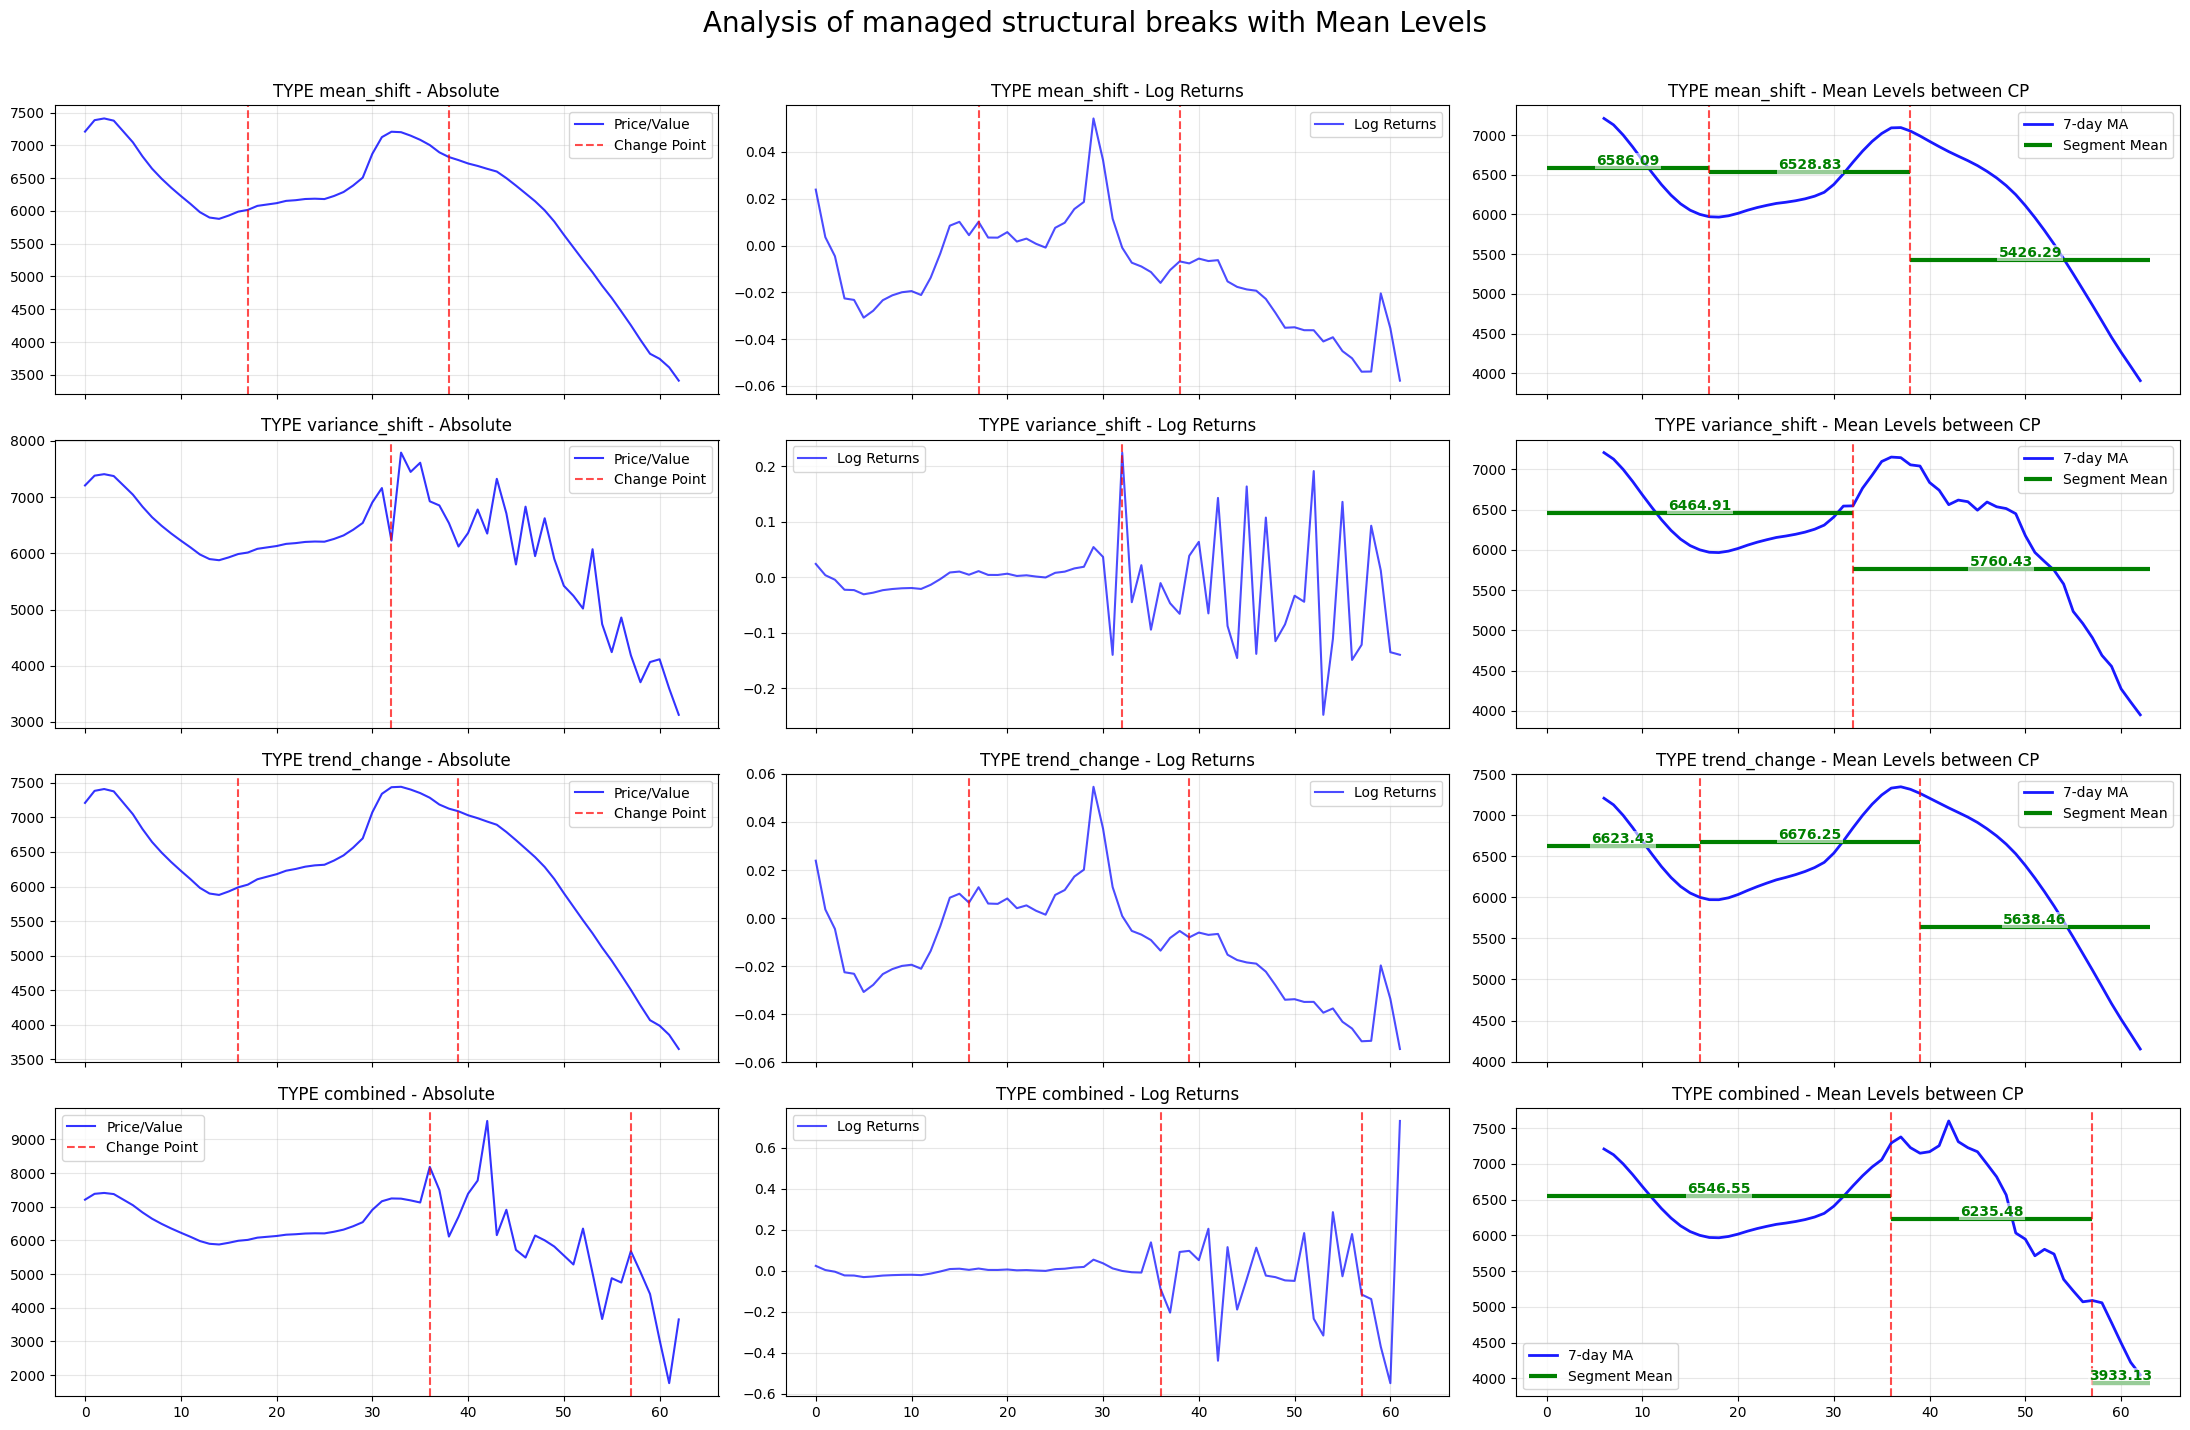

In [3]:
MAGIC_SEED = 819946 
np.random.seed(MAGIC_SEED)
torch.manual_seed(MAGIC_SEED)

n = 800
noise_dim = 20
seq_len = 30
vxx_slice = merged['vxx'].values[n:]
treasures_slice = merged['treasures'].values[n:]
snp_slice = merged['snp'].values[n:]

G = Generator(noise_dim, seq_len)
G.load_state_dict(torch.load("generator.pth")) 

gan_simulator = GANIntegratedSimulation(
    generator=G, 
    noise_dim=noise_dim,
    vix_array=vxx_slice, 
    treasures_array=treasures_slice, 
    snp_array=snp_slice,
    vix_method='log_likelihood_article', 
    treasures_method='ols',    
    forecast_days=63,   
    num_simulations=15
)

vix_sim, treas_sim, snp_sim = gan_simulator.get_processes()
target_series = snp_sim[:, 0] 
injector = ChangePointInjector(target_series, seed=MAGIC_SEED)

injector.plot_all()